#Упражнения: Раздел 1



In [5]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/Dementrrr/ThinkDSP/raw/master/code/thinkdsp.py

import thinkdsp as tdsp

##Упражнение 1.1
Открыл chap01.ipynb, прочитал пояснения и запустил примеры.

In [6]:
cos_sig = tdsp.CosSignal(freq=440, amp=1.0, offset=0)
sin_sig = tdsp.SinSignal(freq=880, amp=0.7, offset=0)

mix = cos_sig + sin_sig
wave = mix.make_wave(duration=1, start=0, framerate=11025)
wave.make_audio()

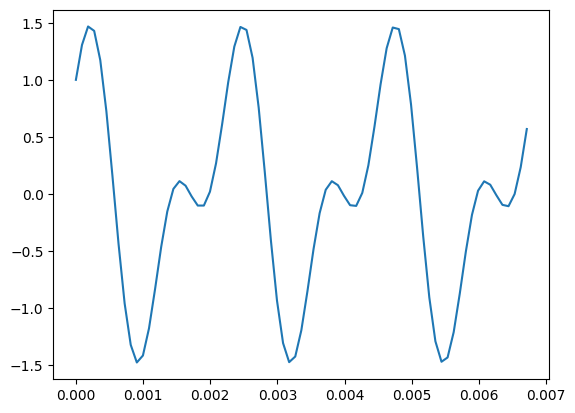

In [7]:
segment = wave.segment(start=0, duration=mix.period*3)
segment.plot()

Writing records/output.wav


/content/thinkdsp.py:1161: UserWarning: Warning: normalizing before quantizing.
  warnings.warn("Warning: normalizing before quantizing.")


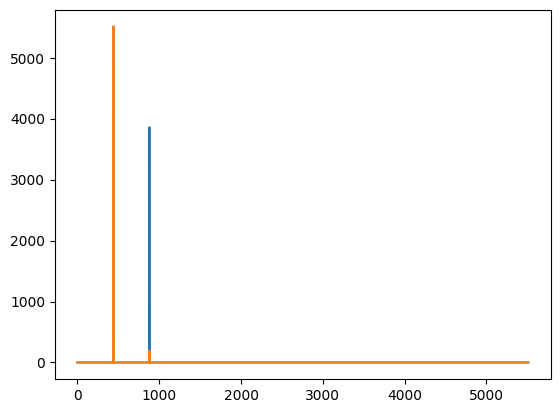

In [8]:
spectrum = wave.make_spectrum()
spectrum.plot()
spectrum.low_pass(500, 0.05)
spectrum.plot()

wave_new = spectrum.make_wave()
wave_new.make_audio()

wave_new.write('records/output.wav')

##Упражнение 1.2
Скачал файл "school_bell.wav" (https://freesound.org/people/deleted_user_7020630/sounds/378394/)


In [9]:
#получаем нужный файл, сохраняем в records/

if not os.path.exists('records/school_bell.wav'):
    !wget -O records/school_bell.wav https://github.com/Dementrrr/ThinkDSP/raw/master/code/school_bell.wav

--2026-05-11 21:55:06--  https://github.com/Dementrrr/ThinkDSP/raw/master/code/school_bell.wav
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/school_bell.wav [following]
--2026-05-11 21:55:07--  https://raw.githubusercontent.com/Dementrrr/ThinkDSP/master/code/school_bell.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1071752 (1.0M) [audio/wav]
Saving to: ‘records/school_bell.wav’

records/school_bell 100%[===================>]   1.02M  --.-KB/s    in 0.007s  

2026-05-11 21:55:07 (144 MB/s) - ‘records/school_bell.wav’ saved [1071752/1071752]



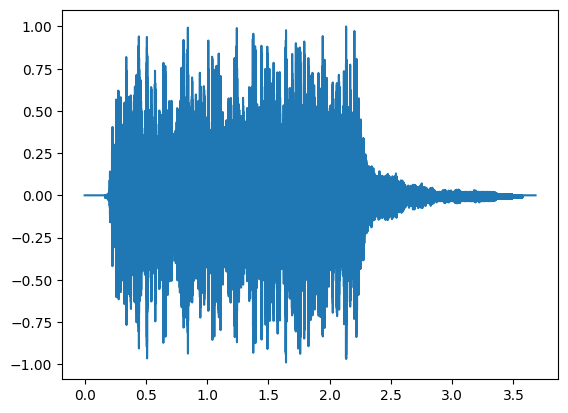

In [10]:
#получаем wave, выводим
wave = tdsp.read_wave('records/school_bell.wav')
wave.plot()
wave.make_audio()

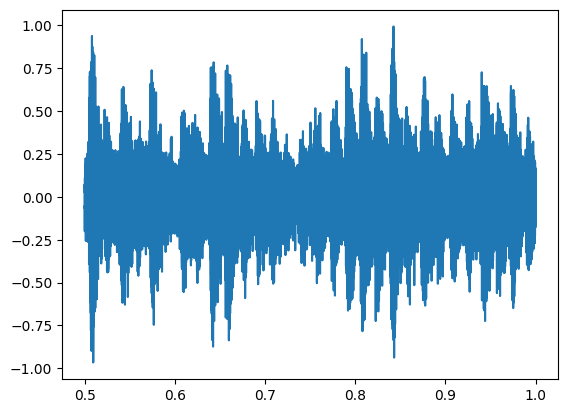

In [11]:
#находим полусекундный сегмент с постоянной высотой
segment = wave.segment(start=0.5, duration=0.5)
segment.plot()
segment.make_audio()

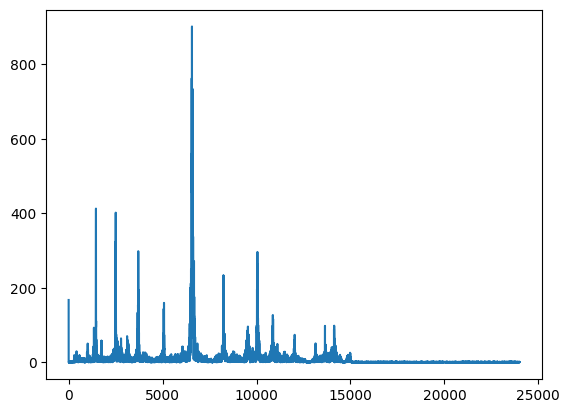

In [12]:
#вычислим спектр сегмента
spectrum = segment.make_spectrum()
spectrum.plot()
#spectrum.peaks()[:25]

Основная частота располагается на 0Гц, однако, так как человеческое ухо не воспринимает частоты ниже 20Гц, можно выделить 1454Гц (близко к F#6) как основную частоту.
Доминирующей частотой можно является 6564Гц (близко к E8).

Проверим, как звучат основная и доминирующая частоты:

Writing records/1_2_fund.wav


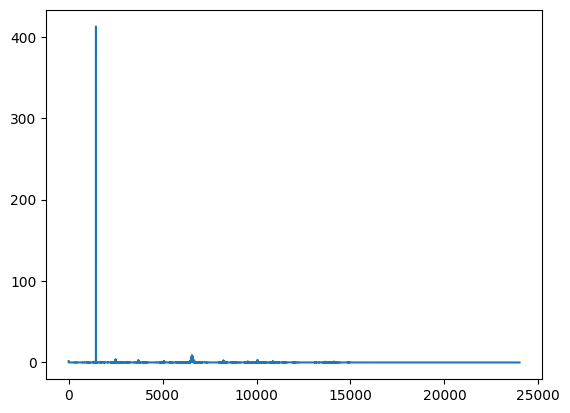

In [13]:
#основная частота
fund_spectrum = segment.make_spectrum()
fund_spectrum.low_pass(1454, 0.01)
fund_spectrum.high_pass(1454, 0.01)
fund_spectrum.plot()
fund_wave = fund_spectrum.make_wave()
fund_wave.make_audio()
fund_wave.write('records/1_2_fund.wav')

Writing records/1_2_dom.wav


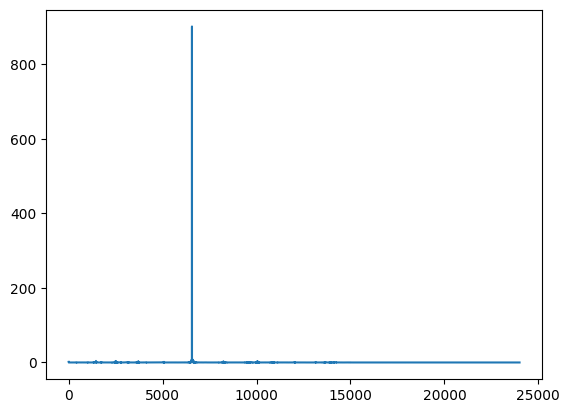

In [14]:
#доминирующая частота
dom_spectrum = segment.make_spectrum()
dom_spectrum.low_pass(6564, 0.01)
dom_spectrum.high_pass(6564, 0.01)
dom_spectrum.plot()
dom_wave = dom_spectrum.make_wave()
dom_wave.make_audio()
dom_wave.write('records/1_2_dom.wav')

Теперь отфильтруем высокие частоты (выше 2000Гц):

Writing records/1_2_low.wav


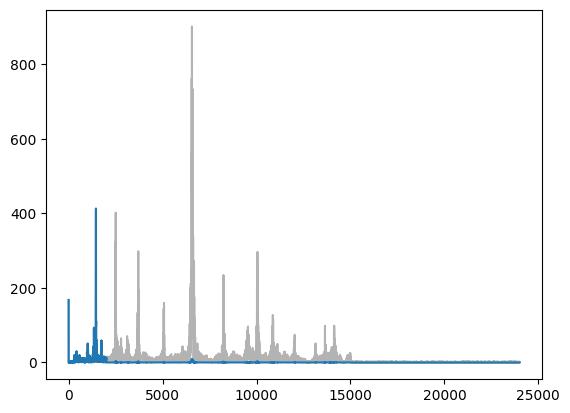

In [15]:
#фильтруем высокие частоты
low_spectrum = segment.make_spectrum()
low_spectrum.low_pass(2000, 0.01)
spectrum.plot(color='0.7')
low_spectrum.plot()

low_wave = low_spectrum.make_wave()
low_wave.make_audio()
low_wave.write('records/1_2_low.wav')

Звук стал более глухим, это очень заметно.

##Упражнение 1.3

Необходимо создать сигнал из SinSignal и CosSignal

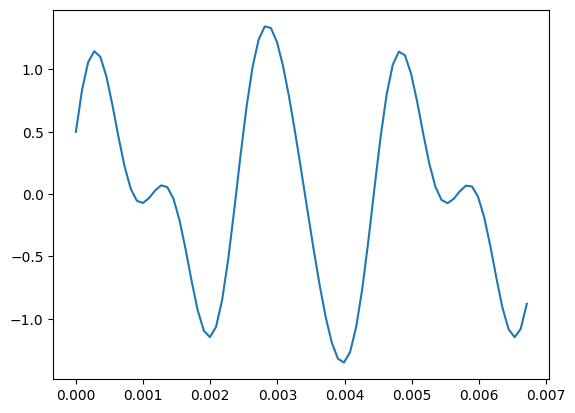

In [16]:
#создаем сигнал, получаем график
signal = tdsp.SinSignal(freq=440, amp=1.0, offset=0) + tdsp.CosSignal(freq=660, amp=0.5, offset=0) + tdsp.SinSignal(freq=880, amp=0.25, offset=0)
signal.plot()

In [17]:
#получим wave
wave = signal.make_wave(duration=1, start=0, framerate=11025)
wave.make_audio()
wave.write('records/1_3_orig.wav')

Writing records/1_3_orig.wav


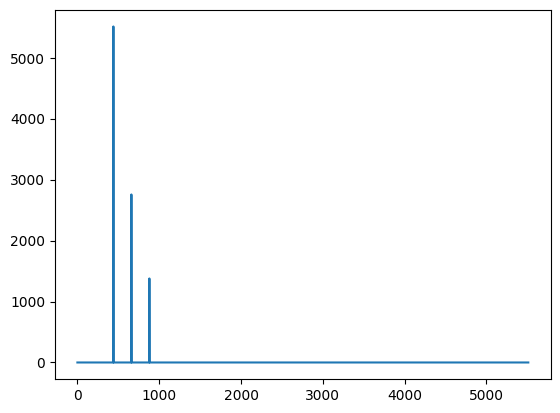

In [18]:
#получим spectrum
spectrum = wave.make_spectrum()
spectrum.plot()

Writing records/1_3_add.wav


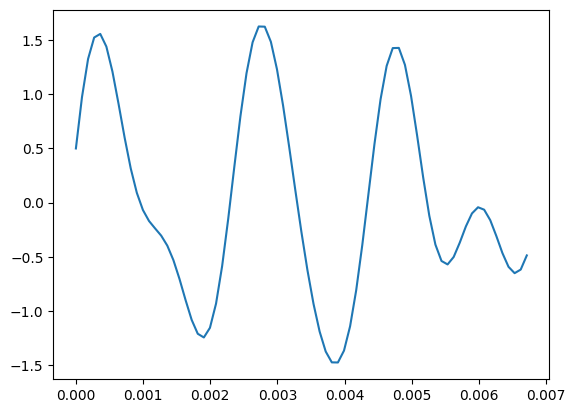

In [19]:
#добавим частотную компоненту, не кратную основным
signal += tdsp.SinSignal(freq=500, amp=0.5, offset=0)
signal.plot()
wave = signal.make_wave(duration=1, start=0, framerate=11025)
wave.make_audio()
wave.write('records/1_3_add.wav')

Слышно расслоение звука, появляется диссонанс

##Упражнение 1.4

Написать функцию stretch()

In [20]:
#для проверки возьмем wave из упражнения 1.2
wave = tdsp.read_wave('records/school_bell.wav')
wave.make_audio()
wave.write('records/1_4_orig.wav')

Writing records/1_4_orig.wav


In [21]:
#функция stretch
def stretch(wave, factor):
    wave.ts *= factor
    wave.framerate /= factor
    return wave

In [22]:
#проверим функцию
stretch(wave, 5).make_audio()
wave.write('records/1_4_stretch.wav')

Writing records/1_4_stretch.wav
